In [1]:
# !pip install git+https://github.com/maods2/mdmp.git

# IS vs VTS on COVID regional data (synthetic multi-individual)

This notebook mirrors [`04-is-vs-vts-multi-individual.ipynb`](04-is-vs-vts-multi-individual.ipynb), but uses the bundled dataset `covid_regional_timeseries` instead of simulation CSVs.

We build **several pseudo-subjects** by repeating the same regional series (with optional tiny jitter so per-subject MDMs are not strictly identical). Then we compare:

- **VTS** (`compute_vts`): `mean`, `median`, and `concatenation` → one representative `(T × N)` series → **one** MDM per method.
- **IS** (`aggregate_individual_structures`): **one MDM per subject** → consensus DAG + pooled `Filt` / Monte Carlo global arcs.

There is no ground-truth DAG here; we compare structures across methods and summarize edge-vote metadata from IS.


In [2]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mdmp import (
    MDM,
    aggregate_individual_structures,
    compute_vts,
    load_dataset,
    plot_arcs,
    plot_idag,
    plot_dag,
)

# --- demo settings (reduce MC samples if the notebook is slow) ---
N_SUBJECTS = 5
NBF = 10
MC_N_SAMPLES = 5_000
TAU = 0.5
RNG = np.random.default_rng(42)
JITTER_SCALE = 0.01  # set to 0.0 for exact copies of the same series


d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load COVID data and build pseudo-subjects

Each subject is a `(T × N)` `DataFrame` with the same column names. With `JITTER_SCALE = 0`, all subjects are identical (VTS mean/median equals the base series; IS votes collapse to one structure).


In [3]:
base = load_dataset("covid_regional_timeseries")
node_names = list(base.columns)
T, N = base.shape
print(f"Base series: T={T}, N={N}, variables={node_names}")
display(base.head())


def make_pseudo_subjects(df, n_subjects, jitter_scale=0.0, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    out = []
    for s in range(n_subjects):
        arr = df.values.astype(float).copy()
        if jitter_scale > 0:
            arr *= 1.0 + jitter_scale * rng.standard_normal(arr.shape)
            arr = np.maximum(arr, 0.0)
        out.append(pd.DataFrame(arr, columns=df.columns))
    return out


dfs = make_pseudo_subjects(base, N_SUBJECTS, jitter_scale=JITTER_SCALE, rng=RNG)
aligned_3d = np.stack([d.values for d in dfs], axis=0)  # (S, T, N)
print(f"Subjects: {len(dfs)}, 3D stack shape {aligned_3d.shape}")


Base series: T=104, N=5, variables=['Southeast', 'Midwest', 'Northeast', 'North', 'South']


,Southeast,Midwest,Northeast,North,South
0,0.0002,0.0000,0.0000,0.0000,0.0000
1,0.0019,0.0001,0.0003,0.0000,0.0000
2,0.0169,0.0031,0.0031,0.0002,0.0021
3,0.0949,0.0156,0.0282,0.0065,0.0221
4,0.1381,0.0247,0.0497,0.0195,0.0391


Subjects: 5, 3D stack shape (5, 104, 5)


## VTS: mean, median, and concatenation

Input can be a 3D array `(S, T, N)`, a list of `(T × N)` arrays, or a long `DataFrame` with `subject_id` (see `mdmp.group_analysis.vts`).


In [4]:
vts_mean = compute_vts(aligned_3d, method="mean")
vts_median = compute_vts(aligned_3d, method="median")
vts_concat = compute_vts(dfs, method="concatenation", return_series=True)

print("VTS shapes (T × N):")
print("  mean        :", vts_mean.vts_data.shape, "n_subjects =", vts_mean.n_subjects)
print("  median      :", vts_median.vts_data.shape)
print("  concatenation:", vts_concat.vts_data.shape, "(S·T rows when return_series=True)")

vts_results = {
    "mean": vts_mean,
    "median": vts_median,
    "concatenation": vts_concat,
}


VTS shapes (T × N):
  mean        : (104, 5) n_subjects = 5
  median      : (104, 5)
  concatenation: (520, 5) (S·T rows when return_series=True)


In [5]:
def fit_mdm_on_vts(vts_result, label):
    df_vts = pd.DataFrame(vts_result.vts_data, columns=node_names)
    model = MDM(df_vts, method="hc", nbf=NBF, verbose=False)
    print(f"MDM on VTS ({label}): {int(np.sum(model.adj_mat))} edges")
    return model


models_vts = {k: fit_mdm_on_vts(r, k) for k, r in vts_results.items()}
adj_vts = {k: (m.adj_mat > 0).astype(int) for k, m in models_vts.items()}


d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\pgmpy\factors\base.py:81: SyntaxWarning: invalid escape sequence '\s'
  For a given set of factors: `args` returns the result of $ \sum_{var \not \in output_vars} \prod \textit{args} $.
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\pgmpy\extern\tabulate.py:151: SyntaxWarning: invalid escape sequence '\h'
  return "\\begin{tabular}{" + tabular_columns_fmt + "}\n\hline"
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\pgmpy\extern\tabulate.py:256: SyntaxWarning: invalid escape sequence '\['
  _invisible_codes = re.compile("\x1b\[\d*m")  # ANSI color codes
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\pgmpy\extern\tabulate.py:257: SyntaxWarning: invalid escape sequence '\['
  _invisible_codes_bytes = re.compile(b"\x1b\[\d*m")  # ANSI color codes
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\pgmpy\models\MarkovNetwork.py:615: SyntaxWarning: invalid escape seq

MDM on VTS (mean): 5 edges


  0%|          | 5/1000000 [00:02<113:31:11,  2.45it/s]


MDM on VTS (median): 5 edges


  0%|          | 7/1000000 [00:11<455:55:43,  1.64s/it] 


MDM on VTS (concatenation): 6 edges


## IS: one MDM per subject, then aggregate

Pass the list of fitted `MDM` objects. With `mc_n_samples > 0`, the pipeline refits each subject on the consensus DAG and fills `global_beta_mc` for inferential edge coefficients; pooled `Filt` supports `plot_arcs`.


In [6]:
print("Fitting per-subject MDMs...")
models_is = [MDM(df, method="hc", nbf=NBF, verbose=False) for df in dfs]
for i, m in enumerate(models_is):
    print(f"  subject {i + 1}: {int(np.sum(m.adj_mat))} edges")

is_agg = aggregate_individual_structures(
    models_is,
    tau=TAU,
    mc_n_samples=MC_N_SAMPLES,
    mc_quantiles=(0.025, 0.975),
    rng=RNG,
)
adj_is = (is_agg.adj_mat > 0).astype(int)
print(is_agg)


Fitting per-subject MDMs...


  0%|          | 6/1000000 [00:02<99:47:31,  2.78it/s] 


  subject 1: 5 edges
  subject 2: 5 edges
  subject 3: 5 edges
  subject 4: 5 edges
  subject 5: 5 edges
ISAggregatedMDMView(nodes=5, time_points=104, edges=5/25, n_subjects=5)


In [7]:
freq = is_agg.metadata.get("edge_frequencies")
counts = is_agg.metadata.get("edge_counts")
removed = is_agg.metadata.get("edges_removed_for_acyclicity", [])

print(f"Threshold tau = {TAU}, n_subjects = {is_agg.n_subjects}")
if freq is not None:
    freq_df = pd.DataFrame(freq, index=node_names, columns=node_names)
    print("\nEdge vote frequencies (fraction of subjects with i → j):")
    display(freq_df.round(3))
if counts is not None:
    print("\nEdge counts:")
    display(pd.DataFrame(counts, index=node_names, columns=node_names))
print(f"\nEdges removed for acyclicity: {removed}")

gb = is_agg.global_beta_mc
if gb is not None:
    n_edges_mc = len(gb.edges)
    n_times = gb.beta_mean.shape[1] if gb.beta_mean is not None else gb.beta_samples.shape[2]
    print(f"\nGlobal beta MC: {n_edges_mc} consensus edges, T={n_times}")
    print(f"  quantile levels: {gb.quantile_levels}")


Threshold tau = 0.5, n_subjects = 5

Edge vote frequencies (fraction of subjects with i → j):


,Southeast,Midwest,Northeast,North,South
Southeast,0.0,0.0,0.0,1.0,0.0
Midwest,1.0,0.0,1.0,0.0,0.0
Northeast,0.0,0.0,0.0,0.0,0.0
North,0.0,0.0,0.0,0.0,0.0
South,1.0,1.0,0.0,0.0,0.0



Edge counts:


,Southeast,Midwest,Northeast,North,South
Southeast,0,0,0,5,0
Midwest,5,0,5,0,0
Northeast,0,0,0,0,0
North,0,0,0,0,0
South,5,5,0,0,0



Edges removed for acyclicity: []

Global beta MC: 5 consensus edges, T=104
  quantile levels: (0.025, 0.975)


## Compare adjacency matrices (heatmaps)

Reference column: MDM on the **base** (unreplicated) series. Off-diagonal Hamming distances count differing directed edges.


  0%|          | 5/1000000 [00:02<117:56:11,  2.36it/s]


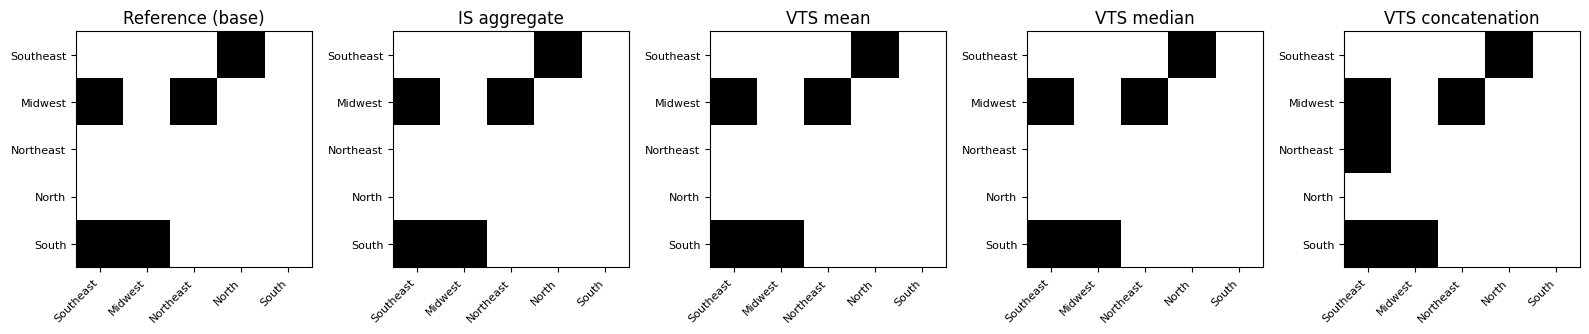

Hamming distance to reference (off-diagonal edges):
  IS aggregate          : 0
  VTS mean              : 0
  VTS median            : 0
  VTS concatenation     : 1


In [8]:
model_ref = MDM(base, method="hc", nbf=NBF, verbose=False)
adj_ref = (model_ref.adj_mat > 0).astype(int)

mats = {
    "Reference (base)": adj_ref,
    "IS aggregate": adj_is,
}
mats.update({f"VTS {k}": v for k, v in adj_vts.items()})


def hamming_offdiag(a, b):
    mask = ~np.eye(a.shape[0], dtype=bool)
    return int(np.sum(a[mask] != b[mask]))


n_panels = len(mats)
fig, axes = plt.subplots(1, n_panels, figsize=(3.2 * n_panels, 3.2))
if n_panels == 1:
    axes = [axes]
for ax, (title, mat) in zip(axes, mats.items()):
    ax.imshow(mat, cmap="Greys", vmin=0, vmax=1)
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xticklabels(node_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(node_names, fontsize=8)
    ax.set_title(title)
fig.tight_layout()
plt.show()

print("Hamming distance to reference (off-diagonal edges):")
for title, mat in mats.items():
    if title.startswith("Reference"):
        continue
    print(f"  {title:22s}: {hamming_offdiag(adj_ref, mat)}")


## Per-subject structures (before aggregation)


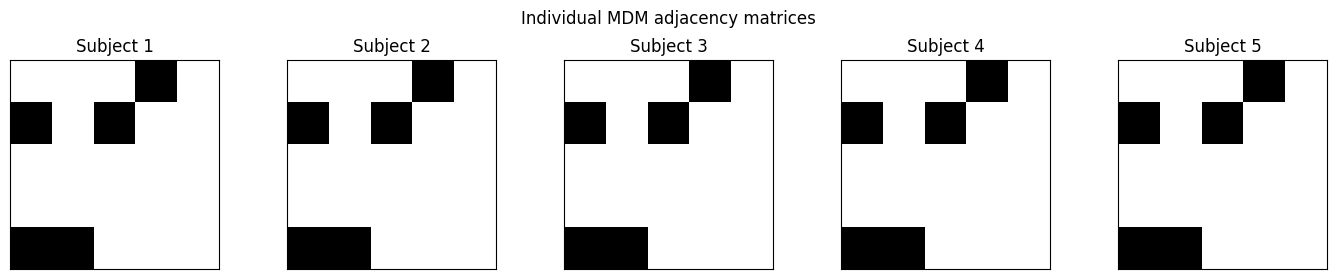

In [9]:
fig, axes = plt.subplots(1, N_SUBJECTS, figsize=(2.8 * N_SUBJECTS, 2.8))
if N_SUBJECTS == 1:
    axes = [axes]
for ax, i, m in zip(axes, range(N_SUBJECTS), models_is):
    mat = (m.adj_mat > 0).astype(int)
    ax.imshow(mat, cmap="Greys", vmin=0, vmax=1)
    ax.set_title(f"Subject {i + 1}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Individual MDM adjacency matrices")
fig.tight_layout()
plt.show()


## DAG plots (`plot_dag`)

`ISAggregatedMDMView` is duck-compatible with `plot_dag`, same as `MDM`.


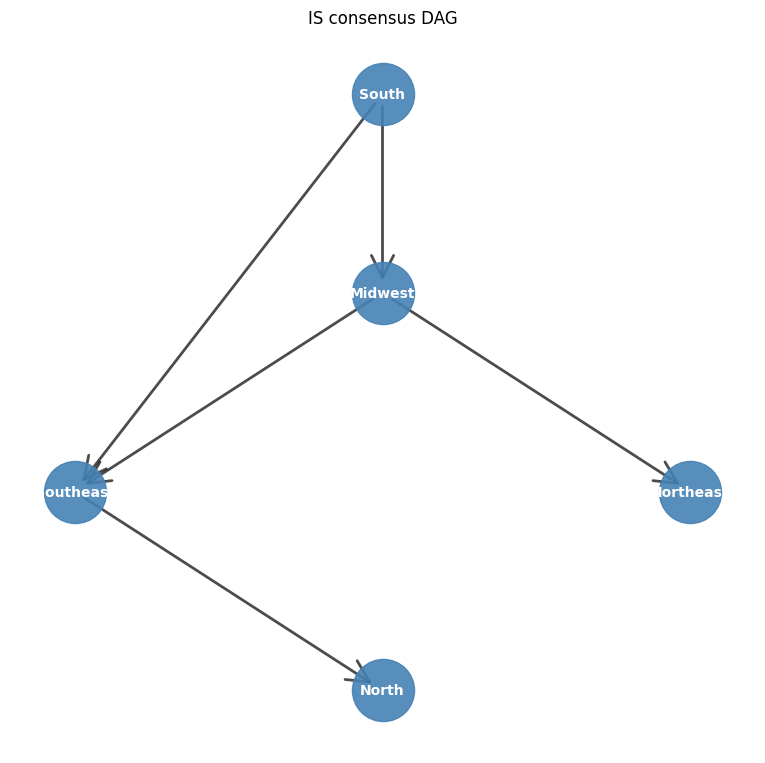

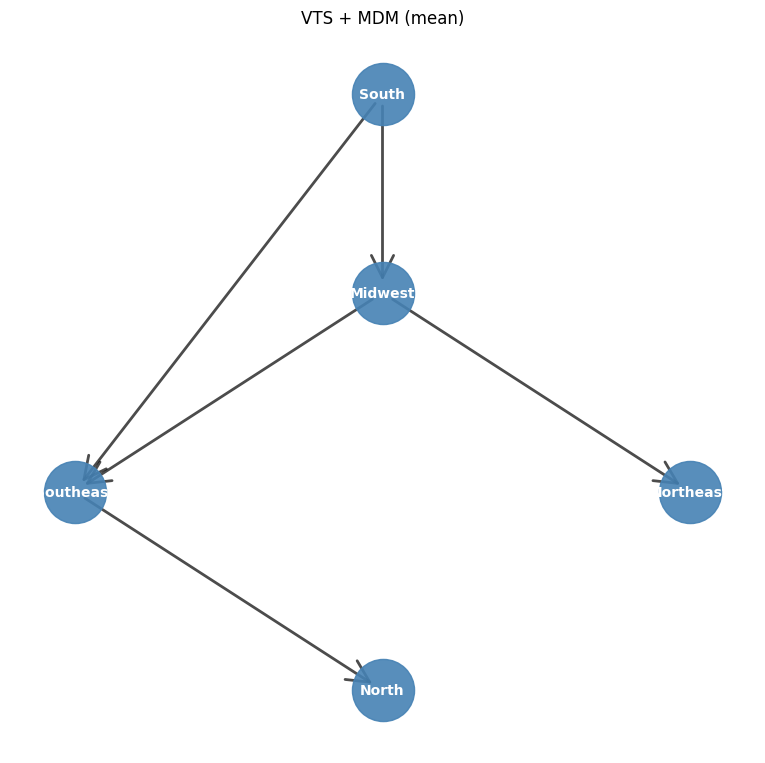

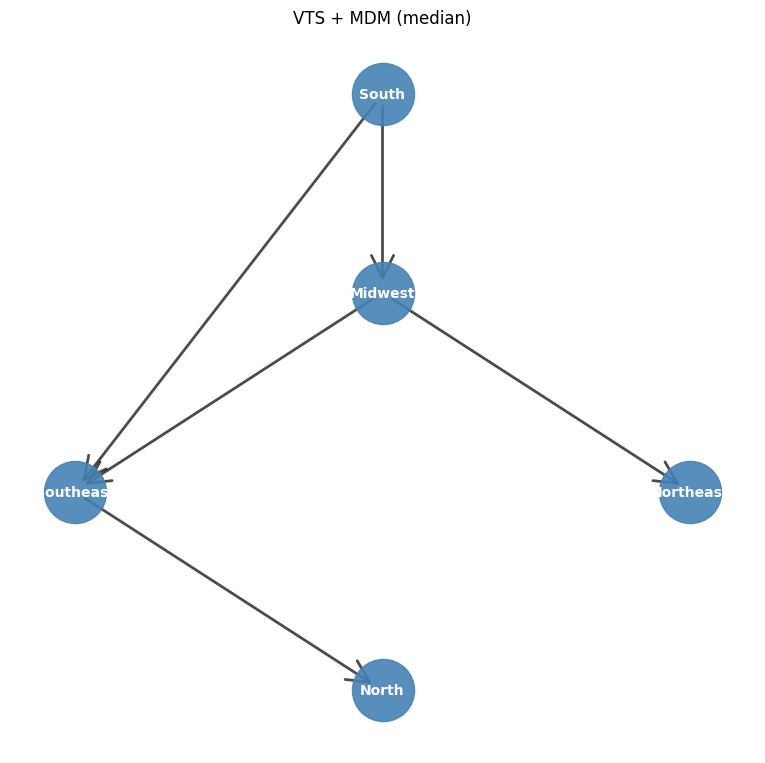

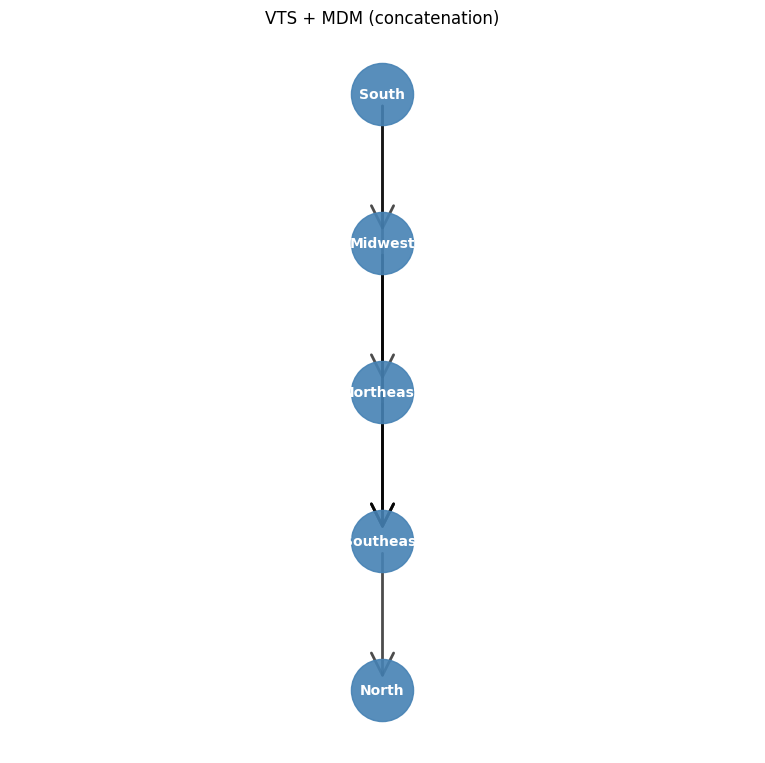

In [10]:
fig = plot_dag(is_agg, plot_type="graph", layout_seed=0)
fig.axes[0].set_title("IS consensus DAG")
plt.show()

for name, model in models_vts.items():
    fig = plot_dag(model, plot_type="graph", layout_seed=0)
    fig.axes[0].set_title(f"VTS + MDM ({name})")
    plt.show()


## Global arcs (`plot_arcs` on IS view)

Uses pooled filtered states on the consensus DAG (plotting adapter on `is_agg.Filt`). Monte Carlo summaries live in `is_agg.global_beta_mc`.


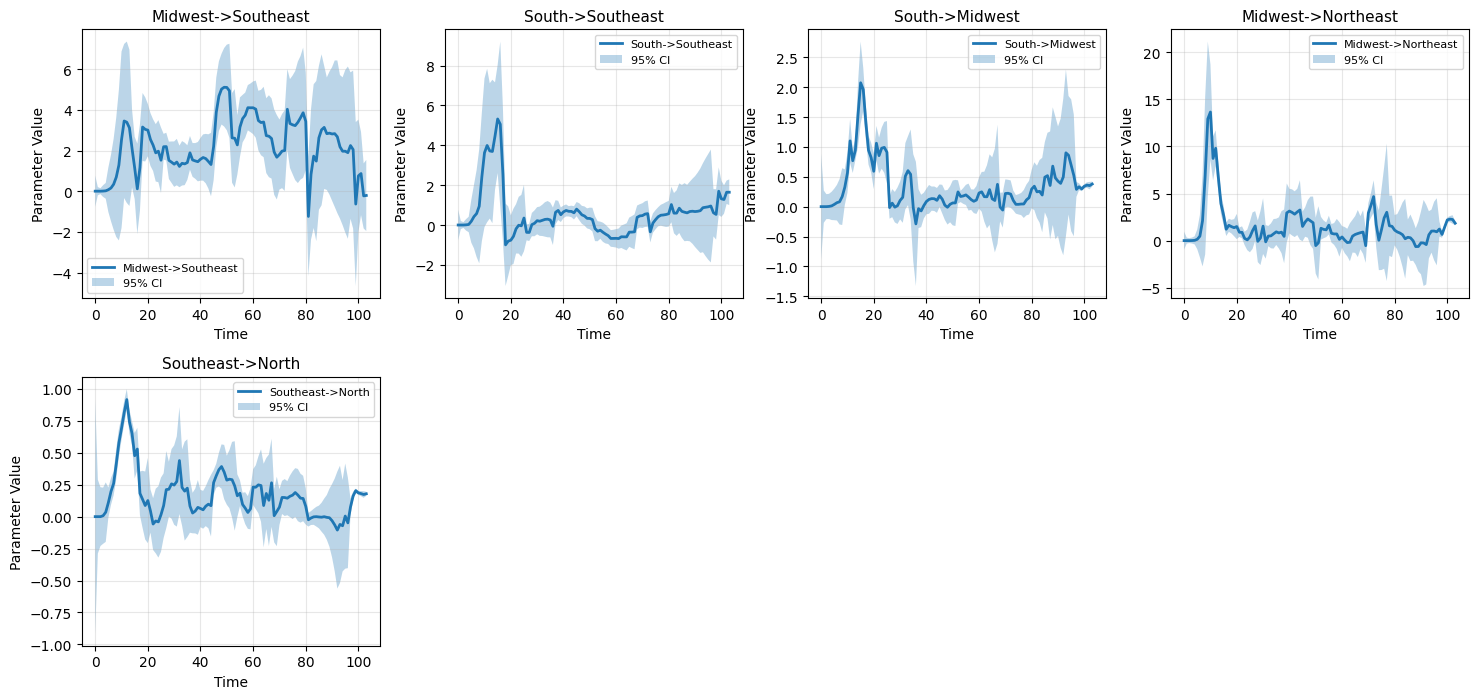

In [11]:
fig_arcs = plot_arcs(is_agg, plot_type="connections", distribution="filt")
# fig_arcs.suptitle("IS pooled filtered connections (consensus DAG)")
plt.show()


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


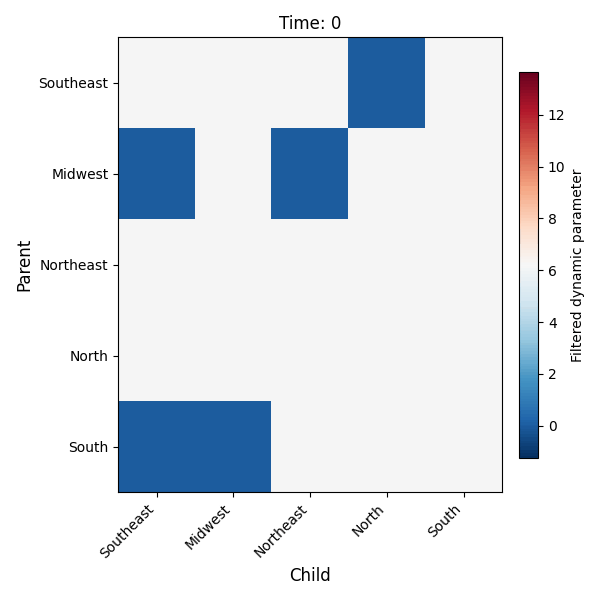

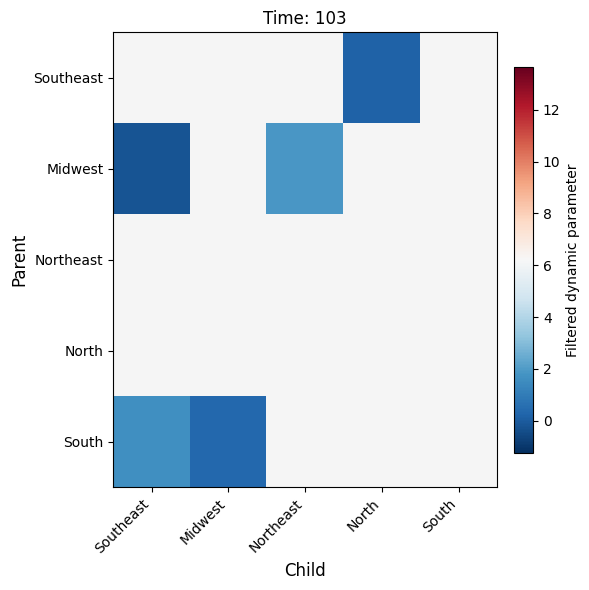

In [13]:
from IPython.display import Image, display

plot_idag(
    is_agg,
    output_gif="is_consensus_dynamic.gif",
    fps=8,
    distribution="filt",
    # show_intercepts=True
    
)

display(Image(filename="is_consensus_dynamic.gif"))